## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

This deliverable will provide you with guidance to help you select an awesome topic and begin to build a polished Capstone project.

__Goal__: Host a lightning talk presentation describing at least three project proposals, including associated data, problem statement, goals, approach, and basic EDA.

### REQUIRED

__Foreach Topic__:
- Problem Statement
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Topic 1 : Turbofan Engine HPC Outlet Static Pressure Sensor Prediction

## Problem Statement

In aviation, physical sensors can degrade, fail, or give noisy readings due to extreme operating conditions. If a critical pressure sensor fails mid-flight, can we accurately estimate its value using the temperatures, speeds, and pressures from the rest of the engine to keep the aircraft flying safely?

## Goals
- Predict the High-Pressure Compressor (HPC) Outlet Static Pressure using other functioning sensors and operational settings.
- Build a highly accurate "virtual sensor" regression model that can act as a fail-safe backup.
- Identify which other engine metrics (like temperatures and fan speeds) are the most important predictors for this pressure.

## Approach
- **Define Target:** Set `HPC Outlet Static Pressure (kPa)` as the target variable for regression.
- **EDA & Feature Selection:** Analyze correlation matrices to identify the strongest predictors (like temperatures and speeds) and drop constant/uninformative sensor columns.
- **Data Preprocessing:** Standardize the scales of the different SI units (temperatures, pressures, speeds) using a scaler.
- **Modeling:** Train regression models (starting with a Linear Regression baseline, moving to Random Forest) to predict the pressure based purely on a single snapshot of the other engine metrics.

## Data Info
Data Source : NASA C-MAPSS Turbofan Engine Degradation Simulation, FD001 subset (Kaggle: `https://www.kaggle.com/datasets/behrad3d/nasa-cmaps/data`). 100 engines run to failure, with 20,630 rows and 26 columns.

## Data Dictionary

| Column | Type | Description |
| :--- | :--- | :--- |
| **engine** | int | Engine No. |
| **cycle** | int | Time, In Cycles |
| **setting1** | float | Operation Setting 1 (sea level)|
| **setting2** | float | Operation Setting 2 (Mach 0)|
| **setting3** | float | Operation Setting 3 (Thrust Generation %)|
| **sensor1** | float | Fan Inlet Temperature (°R) |
| **sensor2** | float | LPC Outlet Temperature (°R) |
| **sensor3** | float | HPC Outlet Temperature (°R) |
| **sensor4** | float | LPT Outlet Temperature (°R) |
| **sensor5** | float | Fan Inlet Pressure (psia) |
| **sensor6** | float | Bypass-Duct Pressure (psia) |
| **sensor7** | float | HPC Outlet Pressure (psia) |
| **sensor8** | float | Physical Fan Speed (rpm) |
| **sensor9** | float | Physical Core Speed (rpm) |
| **sensor10** | float | Engine Pressure Ratio (P50/P2) |
| **sensor11** | float | **target:** HPC Outlet Static Pressure (psia) |
| **sensor12** | float | Ratio of Fuel Flow to Ps30 (pps/psia) |
| **sensor13** | float | Corrected Fan Speed (rpm) |
| **sensor14** | float | Corrected Core Speed (rpm) |
| **sensor15** | float | Bypass Ratio |
| **sensor16** | float | Burner Fuel-Air Ratio |
| **sensor17** | float | Bleed Enthalpy |
| **sensor18** | float | Required Fan Speed |
| **sensor19** | float | Required Fan Conversion Speed |
| **sensor20** | float | High-Pressure Turbines Cool Air Flow |
| **sensor21** | float | Low-Pressure Turbines Cool Air Flow |


## Loading Data


In [32]:
# Load FD001 (space-separated, no header)
col_names = ['engine', 'cycle', 'setting1', 'setting2', 'setting3'] + \
            [f'sensor{i}' for i in range(1, 22)]
df1 = pd.read_csv('./data/train_FD001.txt', sep=r'\s+', header=None, names=col_names)
df1_test = pd.read_csv('./data/test_FD001.txt', sep=r'\s+', header=None, names=col_names)

print(df1.shape)
print(df1_test.shape)

(20631, 26)
(13096, 26)


In [33]:
df1.sample(5)

,engine,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
5187,26,78,0.0002,0.0005,100.0,518.67,642.65,1600.53,1405.42,14.62,...,521.30,2388.15,8133.06,8.4371,0.03,392,2388,100.0,38.75,23.2006
8031,41,206,0.0057,0.0003,100.0,518.67,643.63,1599.01,1419.32,14.62,...,520.97,2388.14,8206.71,8.4998,0.03,395,2388,100.0,38.45,23.1545
12603,64,123,-0.0000,-0.0001,100.0,518.67,642.76,1587.54,1411.35,14.62,...,521.64,2388.10,8140.21,8.4601,0.03,392,2388,100.0,38.88,23.3088
18765,92,251,-0.0002,-0.0002,100.0,518.67,642.25,1589.92,1416.45,14.62,...,521.22,2388.08,8153.92,8.4596,0.03,393,2388,100.0,38.61,23.3122
12235,62,109,0.0017,-0.0002,100.0,518.67,643.17,1596.08,1414.77,14.62,...,521.20,2388.12,8134.86,8.4604,0.03,394,2388,100.0,38.72,23.1983


In [34]:
df1_test.sample(5)

,engine,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
1615,14,33,0.0000,0.0003,100.0,518.67,642.60,1590.58,1409.72,14.62,...,521.70,2388.13,8114.29,8.4406,0.03,393,2388,100.0,38.98,23.2663
12888,99,88,-0.0014,-0.0000,100.0,518.67,641.83,1588.59,1400.48,14.62,...,522.54,2388.06,8152.16,8.3886,0.03,392,2388,100.0,39.02,23.4590
11590,90,138,0.0049,-0.0004,100.0,518.67,642.86,1595.98,1414.66,14.62,...,521.18,2388.09,8145.72,8.4683,0.03,396,2388,100.0,38.62,23.1560
3531,30,1,0.0035,-0.0003,100.0,518.67,642.35,1588.33,1401.91,14.62,...,521.29,2388.13,8125.68,8.4299,0.03,393,2388,100.0,38.77,23.1735
2448,21,14,-0.0025,0.0000,100.0,518.67,642.01,1584.92,1401.35,14.62,...,522.10,2388.04,8135.72,8.3578,0.03,391,2388,100.0,39.02,23.5440


## EDA


In [35]:
# Create a dictionary mapping the current 'sensorX' names to their actual names
sensor_names_mapping = {
    "sensor1": "Fan Inlet Temperature (◦R)",
    "sensor2": "LPC Outlet Temperature (◦R)",
    "sensor3": "HPC Outlet Temperature (◦R)",
    "sensor4": "LPT Outlet Temperature (◦R)",
    "sensor5": "Fan Inlet Pressure (psia)",
    "sensor6": "Bypass-Duct Pressure (psia)",
    "sensor7": "HPC Outlet Pressure (psia)",
    "sensor8": "Physical Fan Speed (rpm)",
    "sensor9": "Physical Core Speed (rpm)",
    "sensor10": "Engine Pressure Ratio(P50/P2)",
    "sensor11": "HPC Outlet Static Pressure (psia)",
    "sensor12": "Ratio of Fuel Flow to Ps30 (pps/psia)",
    "sensor13": "Corrected Fan Speed (rpm)",
    "sensor14": "Corrected Core Speed (rpm)",
    "sensor15": "Bypass Ratio",
    "sensor16": "Burner Fuel-Air Ratio",
    "sensor17": "Bleed Enthalpy",
    "sensor18": "Required Fan Speed",
    "sensor19": "Required Fan Conversion Speed",
    "sensor20": "High-Pressure Turbines Cool Air Flow",
    "sensor21": "Low-Pressure Turbines Cool Air Flow"}

# Rename the columns in the dataframe
df1.rename(columns=sensor_names_mapping, inplace=True)
df1.head()

,engine,cycle,setting1,setting2,setting3,Fan Inlet Temperature (◦R),LPC Outlet Temperature (◦R),HPC Outlet Temperature (◦R),LPT Outlet Temperature (◦R),Fan Inlet Pressure (psia),...,Ratio of Fuel Flow to Ps30 (pps/psia),Corrected Fan Speed (rpm),Corrected Core Speed (rpm),Bypass Ratio,Burner Fuel-Air Ratio,Bleed Enthalpy,Required Fan Speed,Required Fan Conversion Speed,High-Pressure Turbines Cool Air Flow,Low-Pressure Turbines Cool Air Flow
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [36]:
# Define the columns that need conversion
temp_cols = ['Fan Inlet Temperature (◦R)', 'LPC Outlet Temperature (◦R)', 'HPC Outlet Temperature (◦R)', 'LPT Outlet Temperature (◦R)']
pressure_cols = ['Fan Inlet Pressure (psia)', 'Bypass-Duct Pressure (psia)', 'HPC Outlet Pressure (psia)', 'HPC Outlet Static Pressure (psia)']

#Convert Temperatures from Rankine (°R) to Celsius (°C)
for col in temp_cols:
    df1[col] = (df1[col] - 491.67) * (5 / 9)

#Convert Pressures from psia to kPa
for col in pressure_cols:
    df1[col] = df1[col] / 14.503773773

#Rename the columns to reflect the new SI units
unit_updates = {
    'Fan Inlet Temperature (◦R)': 'Fan Inlet Temperature (°C)',
    'LPC Outlet Temperature (◦R)': 'LPC Outlet Temperature (°C)',
    'HPC Outlet Temperature (◦R)': 'HPC Outlet Temperature (°C)',
    'LPT Outlet Temperature (◦R)': 'LPT Outlet Temperature (°C)', 
    'Fan Inlet Pressure (psia)': 'Fan Inlet Pressure (bar)',
    'Bypass-Duct Pressure (psia)': 'Bypass-Duct Pressure (bar)',
    'HPC Outlet Pressure (psia)': 'HPC Outlet Pressure (bar)',
    'HPC Outlet Static Pressure (psia)': 'HPC Outlet Static Pressure (bar)'}

df1.rename(columns=unit_updates, inplace=True)
pd.set_option('display.max_columns', None)
df1.head()

,engine,cycle,setting1,setting2,setting3,Fan Inlet Temperature (°C),LPC Outlet Temperature (°C),HPC Outlet Temperature (°C),LPT Outlet Temperature (°C),Fan Inlet Pressure (bar),Bypass-Duct Pressure (bar),HPC Outlet Pressure (bar),Physical Fan Speed (rpm),Physical Core Speed (rpm),Engine Pressure Ratio(P50/P2),HPC Outlet Static Pressure (bar),Ratio of Fuel Flow to Ps30 (pps/psia),Corrected Fan Speed (rpm),Corrected Core Speed (rpm),Bypass Ratio,Burner Fuel-Air Ratio,Bleed Enthalpy,Required Fan Speed,Required Fan Conversion Speed,High-Pressure Turbines Cool Air Flow,Low-Pressure Turbines Cool Air Flow
0,1,1,-0.0007,-0.0004,100.0,15.0,83.416667,610.016667,504.961111,1.008014,1.489957,38.221777,2388.06,9046.19,1.3,3.272941,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,15.0,83.600000,611.194444,506.372222,1.008014,1.489957,38.179719,2388.04,9044.07,1.3,3.274320,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,15.0,83.711111,609.066667,506.961111,1.008014,1.489957,38.214882,2388.08,9052.94,1.3,3.259152,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,15.0,83.711111,606.177778,505.666667,1.008014,1.489957,38.227982,2388.11,9049.48,1.3,3.249499,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,15.0,83.722222,606.211111,508.083333,1.008014,1.489957,38.196955,2388.06,9055.15,1.3,3.259841,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [37]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   engine                                 20631 non-null  int64  
 1   cycle                                  20631 non-null  int64  
 2   setting1                               20631 non-null  float64
 3   setting2                               20631 non-null  float64
 4   setting3                               20631 non-null  float64
 5   Fan Inlet Temperature (°C)             20631 non-null  float64
 6   LPC Outlet Temperature (°C)            20631 non-null  float64
 7   HPC Outlet Temperature (°C)            20631 non-null  float64
 8   LPT Outlet Temperature (°C)            20631 non-null  float64
 9   Fan Inlet Pressure (bar)               20631 non-null  float64
 10  Bypass-Duct Pressure (bar)             20631 non-null  float64
 11  HPC Outlet Pr

## Feature Engineering


In [38]:
#Engineer the target column: Remaining Useful Life (RUL)
max_cycle = df1.groupby('engine')['cycle'].transform('max')
df1['RUL'] = max_cycle - df1['cycle']

df1[['engine', 'cycle', 'RUL']].head()

,engine,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


As engines age, their baseline sensor readings shift. You can create a categorical column that bins the current cycle (age) of the engine into distinct lifecycle stages.

In [39]:
#Categorical Feature: Engine Wear Stage
#Bin the 'cycle' into Early, Mid, and Late stages of life
bins = [0, 100, 200, 400] # Adjust based on max cycle distribution
labels = ['Early-Life', 'Mid-Life', 'Late-Life']

df1['Wear_Stage'] = pd.cut(df1['cycle'], bins=bins, labels=labels).astype(str)

df1[['engine', 'cycle', 'Wear_Stage']].head()

,engine,cycle,Wear_Stage
0,1,1,Early-Life
1,1,2,Early-Life
2,1,3,Early-Life
3,1,4,Early-Life
4,1,5,Early-Life


In aviation, a single sensor reading can sometimes spike due to noise. Providing your model with the "trend" over the last few cycles is often more predictive than just the current snapshot. Calculating a 5-cycle moving average for key sensors.

In [40]:
#Time-Series Feature: 5-Cycle Rolling Averages for highly correlated sensors
#Grouping by 'engine' so the rolling average doesn't leak from one engine's data into another
top_sensors = ['LPT Outlet Temperature (°C)', 'HPC Outlet Temperature (°C)', 'Physical Fan Speed (rpm)']

for col in top_sensors:
    # Calculate the rolling mean, min_periods=1 ensures we don't get NaNs for the first 4 cycles
    df1[f'{col}_rolling_mean_over_5_cycles'] = df1.groupby('engine')[col].transform(lambda x: x.rolling(window=5, min_periods=1).mean())

Physics-based features are highly valued in engineering datasets. The ratio between the temperature coming out of the Low-Pressure Compressor (LPC) and the High-Pressure Compressor (HPC) can act as a proxy for the thermal efficiency of the compressor stage.

In [41]:
#Interaction Feature: Compressor Thermal Ratio
# Ratio of HPC Temperature to LPC Temperature
df1['Compressor_Thermal_Ratio'] = df1['HPC Outlet Temperature (°C)'] / df1['LPC Outlet Temperature (°C)']

In [43]:
# Preview the newly engineered features
feature_cols = [col for col in df1.columns if 'Wear_Stage' in col or 'rolling' in col or 'Ratio' in col]
df1[['engine', 'cycle'] + feature_cols].head(10)

,engine,cycle,Engine Pressure Ratio(P50/P2),Ratio of Fuel Flow to Ps30 (pps/psia),Bypass Ratio,Burner Fuel-Air Ratio,Wear_Stage,LPT Outlet Temperature (°C)_rolling_mean_over_5_cycles,HPC Outlet Temperature (°C)_rolling_mean_over_5_cycles,Physical Fan Speed (rpm)_rolling_mean_over_5_cycles,Compressor_Thermal_Ratio
0,1,1,1.3,521.66,8.4195,0.03,Early-Life,504.961111,610.016667,2388.0600,7.312887
1,1,2,1.3,522.28,8.4318,0.03,Early-Life,505.666667,610.605556,2388.0500,7.310938
2,1,3,1.3,522.42,8.4178,0.03,Early-Life,506.098148,610.092593,2388.0600,7.275816
3,1,4,1.3,522.86,8.3682,0.03,Early-Life,505.990278,609.113889,2388.0725,7.241306
4,1,5,1.3,522.19,8.4294,0.03,Early-Life,506.408889,608.533333,2388.0700,7.240743
5,1,6,1.3,521.68,8.4108,0.03,Early-Life,506.161111,607.952222,2388.0620,7.264508
6,1,7,1.3,522.32,8.3974,0.03,Early-Life,505.564444,608.007778,2388.0580,7.298256
7,1,8,1.3,522.47,8.4076,0.03,Early-Life,505.205556,607.448889,2388.0420,7.232355
8,1,9,1.3,521.79,8.3728,0.03,Early-Life,504.420000,608.358889,2388.0300,7.306813
9,1,10,1.3,521.79,8.4286,0.03,Early-Life,503.780000,609.291111,2388.0280,7.328512


In [14]:
df1.sample(5)

,engine,cycle,setting1,setting2,setting3,Fan Inlet Temperature (°C),LPC Outlet Temperature (°C),HPC Outlet Temperature (°C),LPT Outlet Temperature (°C),Fan Inlet Pressure (bar),Bypass-Duct Pressure (bar),HPC Outlet Pressure (bar),Physical Fan Speed (rpm),Physical Core Speed (rpm),Engine Pressure Ratio(P50/P2),HPC Outlet Static Pressure (bar),Ratio of Fuel Flow to Ps30 (pps/psia),Corrected Fan Speed (rpm),Corrected Core Speed (rpm),Bypass Ratio,Burner Fuel-Air Ratio,Bleed Enthalpy,Required Fan Speed,Required Fan Conversion Speed,High-Pressure Turbines Cool Air Flow,Low-Pressure Turbines Cool Air Flow,RUL,Wear_Stage,LPT Outlet Temperature (°C)_rolling_mean_over_5_cycles,HPC Outlet Temperature (°C)_rolling_mean_over_5_cycles,Physical Fan Speed (rpm)_rolling_mean_over_5_cycles,Compressor_Thermal_Ratio
2310,11,175,-0.0013,-0.0004,100.0,15.0,84.016667,608.894444,506.483333,1.008014,1.489957,38.165929,2388.02,9077.88,1.3,3.269494,521.66,2388.12,8159.93,8.4273,0.03,393,2388,100.0,38.76,23.2410,65,Mid-Life,508.262222,610.115556,2388.066,7.247305
3420,17,116,0.0030,0.0003,100.0,15.0,83.561111,610.372222,503.788889,1.008014,1.489957,38.194887,2388.02,9066.38,1.3,3.250189,522.15,2388.00,8147.49,8.4296,0.03,390,2388,100.0,38.80,23.4046,160,Mid-Life,504.393333,608.255556,2388.034,7.304501
4346,21,179,0.0026,-0.0004,100.0,15.0,84.311111,613.888889,516.055556,1.008014,1.489957,38.114908,2388.11,9123.59,1.3,3.299141,520.68,2388.12,8188.25,8.4978,0.03,394,2388,100.0,38.64,23.1996,16,Mid-Life,515.113333,614.027778,2388.126,7.281234
20492,100,62,-0.0024,-0.0001,100.0,15.0,83.977778,607.127778,511.000000,1.008014,1.489957,38.152829,2388.06,9069.14,1.3,3.272252,521.62,2388.05,8140.58,8.4139,0.03,393,2388,100.0,38.90,23.2975,138,Early-Life,508.682222,609.520000,2388.064,7.229624
6744,34,133,0.0006,0.0000,100.0,15.0,83.733333,613.294444,513.872222,1.008014,1.489957,38.131455,2388.10,9082.99,1.3,3.290178,520.97,2388.10,8157.08,8.4620,0.03,395,2388,100.0,38.84,23.2767,62,Mid-Life,512.570000,611.573333,2388.100,7.324376


## Plotting

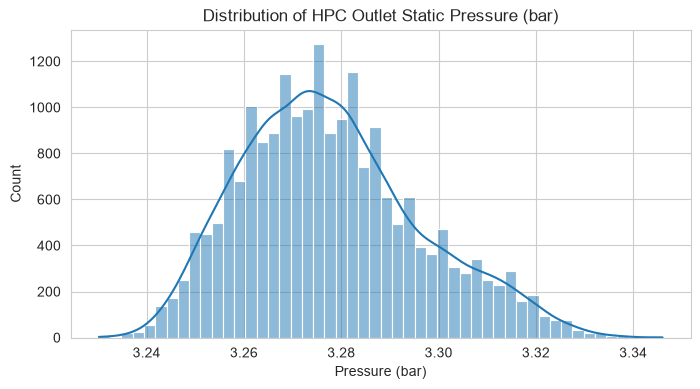

Numerical features: 31
Categorical features: 1

Null values in dataset:
0 maximum nulls in any single column

Correlation with HPC Outlet Static Pressure (bar):
 HPC Outlet Static Pressure (bar)                          1.000000
LPT Outlet Temperature (°C)_rolling_mean_over_5_cycles    0.901523
HPC Outlet Temperature (°C)_rolling_mean_over_5_cycles    0.852948
Physical Fan Speed (rpm)_rolling_mean_over_5_cycles       0.840869
LPT Outlet Temperature (°C)                               0.830136
Physical Fan Speed (rpm)                                  0.782213
Bypass Ratio                                              0.780913
Corrected Fan Speed (rpm)                                 0.780761
LPC Outlet Temperature (°C)                               0.740020
Bleed Enthalpy                                            0.722296
HPC Outlet Temperature (°C)                               0.695900
cycle                                                     0.634385
Compressor_Thermal_Ratio          

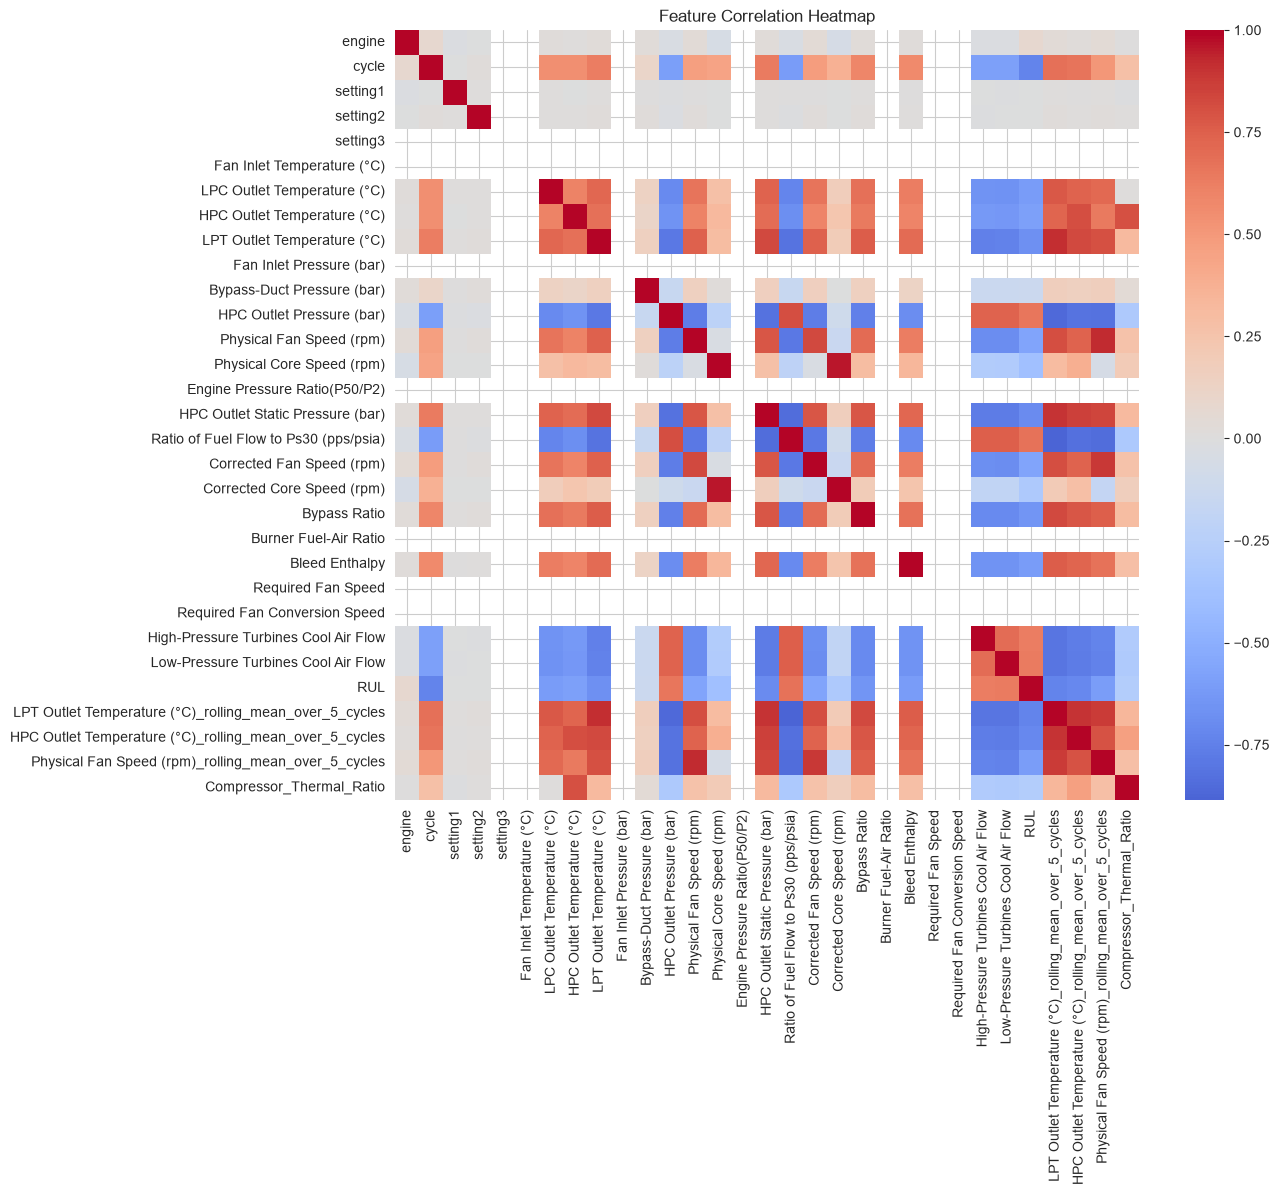

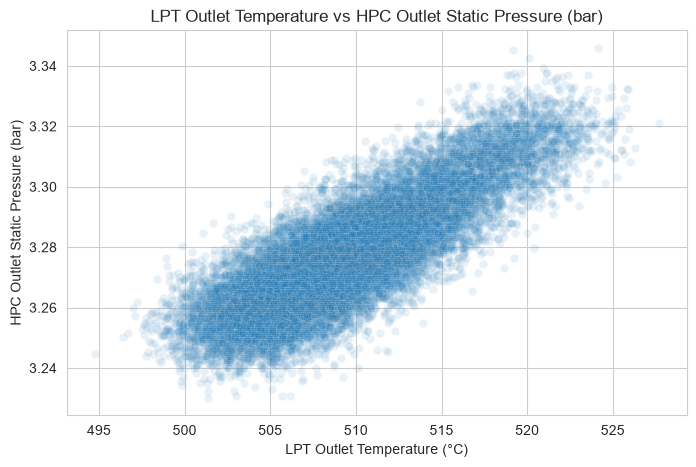

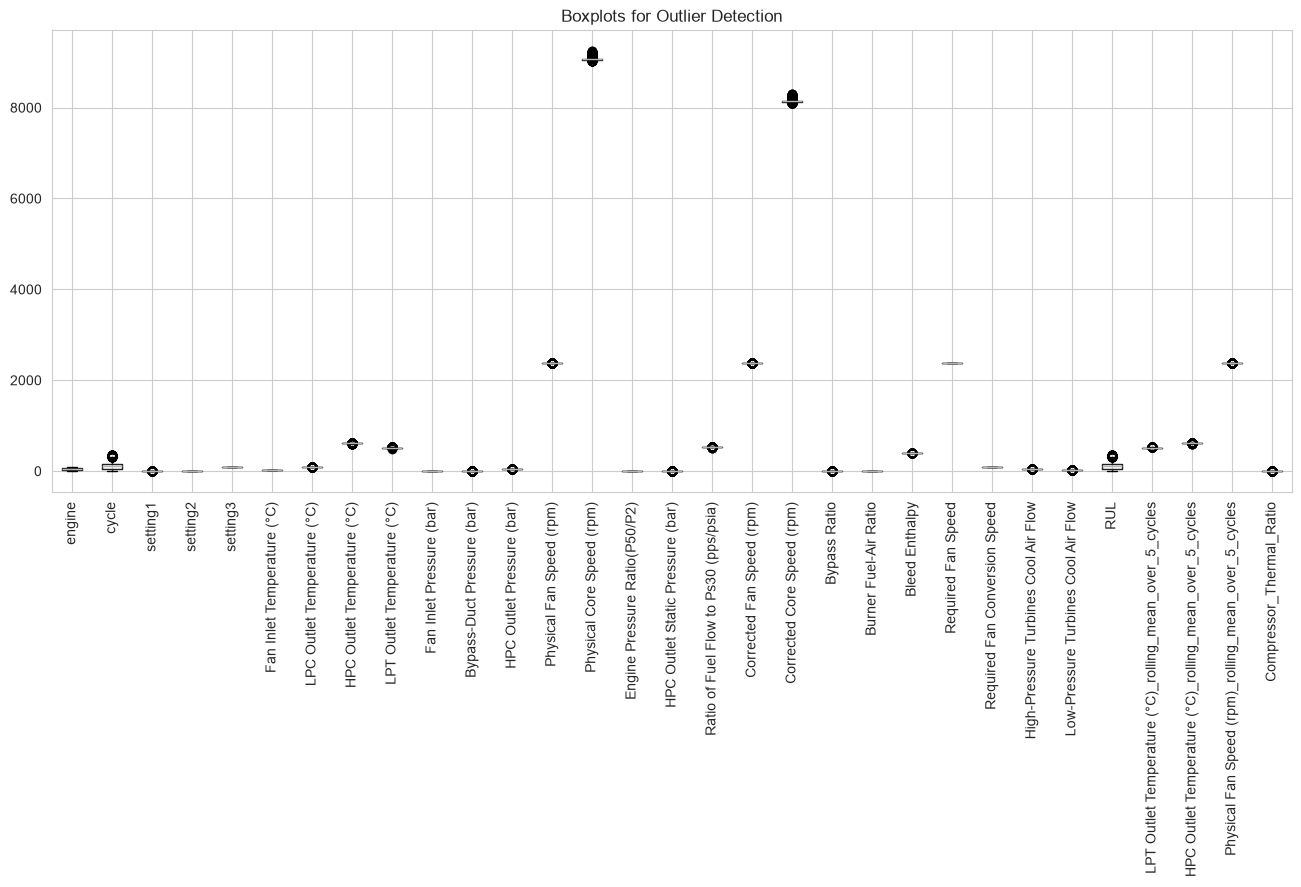

In [15]:
#Target column = HPC Outlet Static Pressure (bar)
target_col = 'HPC Outlet Static Pressure (bar)'

#Is the target categorical or continuous? Plot distribution
#The pressure is continuous (regression problem)
plt.figure(figsize=(8, 4))
sns.histplot(df1[target_col], bins=50, kde=True)
plt.title('Distribution of HPC Outlet Static Pressure (bar)')
plt.xlabel('Pressure (bar)')
plt.show()

#Feature types (categorical / numerical)
numerical_cols = df1.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df1.select_dtypes(exclude=np.number).columns.tolist()
print(f'Numerical features: {len(numerical_cols)}')
print(f'Categorical features: {len(categorical_cols)}')

#Null values per feature
print("\nNull values in dataset:")
print(df1.isnull().sum().max(), "maximum nulls in any single column")
# Plan: CMAPSS is simulated and typically has no missing values; if any appear, 
# forward-fill per engine since these are sequential sensor readings.

#Correlation with target and with each other
corr_with_target = df1.corr(numeric_only=True)[target_col].sort_values(ascending=False)
print(f"\nCorrelation with {target_col}:\n", corr_with_target)

plt.figure(figsize=(12, 10))
sns.heatmap(df1.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

#Visualize relationship between target and a highly correlated feature
#Using LPT Outlet Temperature based on previous correlation knowledge
plt.figure(figsize=(8, 5))
sns.scatterplot(x='LPT Outlet Temperature (°C)', y=target_col, data=df1, alpha=0.1)
plt.title(f'LPT Outlet Temperature vs {target_col}')
plt.show()

#Outliers
plt.figure(figsize=(16, 6))
df1[numerical_cols].boxplot(rot=90)
plt.title('Boxplots for Outlier Detection')
plt.show()

## Future Plan
Sensors with constant/near-zero variance will be dropped before modeling. True outliers in physical sensor ranges are likely valid extreme operational states, not data errors, so we will cap them using a robust scaler rather than removing them.

# Topic 2 : Steam Game Success/Rating Prediction

## Problem Statement

With tens of thousands of games releasing on Steam, most never gain traction, while a select few capture massive, highly engaged audiences. Can we predict a game's peak concurrent player count (Peak CCU) based on its release metadata to understand what drives viral player engagement?

## Goals
- Predict the Peak CCU of a Steam game using its pricing, platform support, and genre metadata.

- Identify which structured factors most strongly correlate with high concurrent player counts

## Approach
- Define Target: Set Peak CCU as the continuous target variable for a regression problem.
- Data Transformation: Apply a log transformation to the target variable (log1p) to handle its extreme right skew (as the vast majority of games have 0–10 CCU, while outliers have hundreds of thousands).
- Modeling: Train regression models (starting with a baseline Linear Regression, moving to Random Forest or XGBoost) to predict the log-transformed Peak CCU.

## Data Info
Data Source : Steam Games Dataset (Kaggle: `https://www.kaggle.com/datasets/fronkongames/steam-games-dataset`). 125,855 rows and 39 columns.

## Data Dictionary
| Column | Type | Description |
| :--- | :--- | :--- |
| **AppID** | int | Unique Steam application ID |
| **Name** | object | Game title |
| **Release date** | object | Release date on Steam |
| **Estimated owners** | object | Estimated owner range (e.g., 0 - 20000) |
| **Peak CCU** | int | **Target:** Peak concurrent users |
| **Required age** | float | Minimum required age to play |
| **Price** | float | Price in USD |
| **DiscountDLC count** | int | Number of DLCs or discount events |
| **About the game** | object | Long-form description of the game |
| **Supported languages** | object | List of text/UI languages supported |
| **Full audio languages** | object | List of fully voiced languages supported |
| **Reviews** | object | Summary or link to reviews |
| **Header image** | object | URL to the game's header/banner image |
| **Website** | object | Game's official website URL |
| **Support url** | object | Developer support URL |
| **Support email** | object | Developer support email |
| **Windows** | bool | Available on Windows (True/False) |
| **Mac** | bool | Available on Mac (True/False) |
| **Linux** | bool | Available on Linux (True/False) |
| **Metacritic score** | int | Official Metacritic score (0 if none) |
| **Metacritic url** | object | URL to Metacritic review page |
| **User score** | int | Steam user score metric |
| **Positive** | int | Number of positive reviews |
| **Negative** | int | Number of negative reviews |
| **Score rank** | float | Global ranking based on review scores |
| **Achievements** | int | Number of unlockable Steam achievements |
| **Recommendations** | int | Number of official Steam recommendations |
| **Notes** | object | Additional patch notes or developer notes |
| **Average playtime forever** | int | Average total playtime (minutes) |
| **Average playtime two weeks** | int | Average playtime in the last two weeks (minutes) |
| **Median playtime forever** | int | Median total playtime (minutes) |
| **Median playtime two weeks** | int | Median playtime in the last two weeks (minutes) |
| **Developers** | object | Studio(s) that developed the game |
| **Publishers** | object | Company/entities that published the game |
| **Categories** | object | Game categories (e.g., Single-player, Multi-player) |
| **Genres** | object | Genre tags (e.g., Action, RPG, Casual) |
| **Tags** | object | User-defined tags (comma-separated) |
| **Screenshots** | object | URLs to store page screenshots |
| **Movies** | object | URLs to store page video trailers |

In [2]:
df2 = pd.read_csv('./data/steam_games.csv', index_col= False)
pd.set_option('display.max_columns', None)
print(df2.shape)

(125855, 39)


In [3]:
print(df2.columns.tolist())
df2.head()

['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price', 'DiscountDLC count', 'About the game', 'Supported languages', 'Full audio languages', 'Reviews', 'Header image', 'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score', 'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations', 'Notes', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks', 'Developers', 'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,NaN,0,252,3,NaN,0,231,NaN,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,NaN,0,21,3,NaN,0,0,NaN,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],['Korean'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,yujingamesc@gmail.com,True,False,False,0,NaN,0,0,0,NaN,19,0,The game includes the following elements. 1. G...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...


## EDA

The columns in this dataset are shifted to the right from the `DiscountDLC` count column onwards, thats because of pandas merging the `Dicount` and `DLC count` columns which results in this issue which needs to be addressed

In [4]:
corrected_columns = [
    'AppID', 'Name', 'Release_date', 'Estimated_owners', 'Peak_CCU', 
    'Required_age', 'Price', 'Discount', 'DLC_count', 'About_the_game', 
    'Supported_languages', 'Full_audio_languages', 'Reviews', 'Header_image', 
    'Website', 'Support_url', 'Support_email', 'Windows', 'Mac', 'Linux', 
    'Metacritic_score', 'Metacritic_url', 'User_score', 'Positive', 'Negative', 
    'Score_rank', 'Achievements', 'Recommendations', 'Notes', 
    'Average_playtime_forever', 'Average_playtime_two_weeks', 
    'Median_playtime_forever', 'Median_playtime_two_weeks', 
    'Developers', 'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots'
]

df2.columns = corrected_columns

In [5]:
df2.shape

(125855, 39)

In [6]:
df2.dtypes

AppID                           int64
Name                              str
Release_date                      str
Estimated_owners                  str
Peak_CCU                        int64
Required_age                    int64
Price                         float64
Discount                        int64
DLC_count                       int64
About_the_game                    str
Supported_languages               str
Full_audio_languages              str
Reviews                           str
Header_image                      str
Website                           str
Support_url                       str
Support_email                     str
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic_score                int64
Metacritic_url                    str
User_score                      int64
Positive                        int64
Negative                        int64
Score_rank                    float64
Achievements

In [7]:
df2['Peak_CCU'].value_counts()

Peak_CCU
0       106175
1         6529
2         2506
3         1428
4          931
         ...  
4696         1
2928         1
352          1
1050         1
1756         1
Name: count, Length: 1110, dtype: int64

In [12]:
df2.isnull().sum()

AppID                              0
Name                               1
Release date                       0
Estimated owners                   0
Peak CCU                           0
Required age                       0
Price                              0
Discount                           0
DLC count                          0
About the game                  8462
Supported languages                0
Full audio languages               0
Reviews                       113674
Header image                      81
Website                        75335
Support url                    70560
Support email                  22630
Windows                            0
Mac                                0
Linux                              0
Metacritic score                   0
Metacritic url                121597
User score                         0
Positive                           0
Negative                           0
Score rank                    125815
Achievements                       0
R

In [9]:
#Drop columns with massive missing data or irrelevant string types (URLs, Emails, raw text)
#Score_rank is almost entirely empty.
#URLs and emails don't help regression models unless heavily engineered.
cols_to_drop = [
    'Reviews', 'Website', 'Support_url', 'Metacritic_url', 'Score_rank', 'Notes', 
    'Support_email', 'Header_image', 'Screenshots', 'About_the_game'
]
df2_clean = df2.drop(columns=cols_to_drop, errors='ignore')

#Impute (Fill) missing values for categorical features
#We will fill these with 'Unknown' so we don't lose the rows
cat_cols_to_fill = ['Developers', 'Publishers', 'Categories', 'Genres', 'Tags']
for col in cat_cols_to_fill:
    df2_clean[col] = df2_clean[col].fillna('Unknown')

#Drop any remaining rows with missing values 
#(If any remain, they are so few that it's safer to drop the rows than guess)
df2_clean = df2_clean.dropna()

#Verify the clean dataset
print(f"Original Shape: {df2.shape}")
print(f"Cleaned Shape: {df2_clean.shape}")
print(f"\nRemaining Missing Values: {df2_clean.isnull().sum().max()}")

Original Shape: (125855, 39)
Cleaned Shape: (125854, 29)

Remaining Missing Values: 0


## Feature Engineering

In [16]:
#Count the number of tags, categories, and supported languages
#Games with more tags or languages might reach wider audiences

# Count elements by counting the commas + 1
df2_clean['Num_Languages'] = df2_clean['Supported_languages'].str.count(',') + 1
df2_clean['Num_Categories'] = df2_clean['Categories'].str.count(',') + 1
df2_clean['Num_Tags'] = df2_clean['Tags'].str.count(',') + 1

# Drop the original complex list columns to keep the dataframe purely numerical/boolean
cols_to_drop_complex = ['Name', 'Release_date', 'Supported_languages', 
                        'Full_audio_languages', 'Developers', 'Publishers', 
                        'Categories', 'Genres', 'Tags', 'Estimated_owners']
df2_clean.drop(columns=cols_to_drop_complex, errors='ignore', inplace=True)
print(df2_clean.dtypes)

AppID                           int64
Peak_CCU                        int64
Required_age                    int64
Price                         float64
Discount                        int64
DLC_count                       int64
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic_score                int64
User_score                      int64
Positive                        int64
Negative                        int64
Achievements                    int64
Recommendations                 int64
Average_playtime_forever        int64
Average_playtime_two_weeks      int64
Median_playtime_forever         int64
Median_playtime_two_weeks       int64
Num_Languages                   int64
Num_Categories                  int64
Num_Tags                        int64
dtype: object


In [18]:
df2_clean.sample(5)

,AppID,Peak_CCU,Required_age,Price,Discount,DLC_count,Windows,Mac,Linux,Metacritic_score,User_score,Positive,Negative,Achievements,Recommendations,Average_playtime_forever,Average_playtime_two_weeks,Median_playtime_forever,Median_playtime_two_weeks,Num_Languages,Num_Categories,Num_Tags
16821,3301260,1,0,0.74,75,0,True,False,False,0,0,21,1,69,0,0,0,0,0,10,5,13
61374,2214840,0,0,1.99,0,0,True,False,False,0,0,48,1,8,0,0,0,0,0,1,2,20
42705,791410,0,0,0.00,0,1,True,False,False,0,0,0,0,40,0,0,0,0,0,2,8,1
117451,2491130,0,0,1.64,67,0,True,False,False,0,0,19,2,21,0,0,0,0,0,3,3,20
89216,907670,0,0,5.99,60,1,True,False,False,0,0,203,7,20,204,0,0,0,0,11,6,20


## Plotting

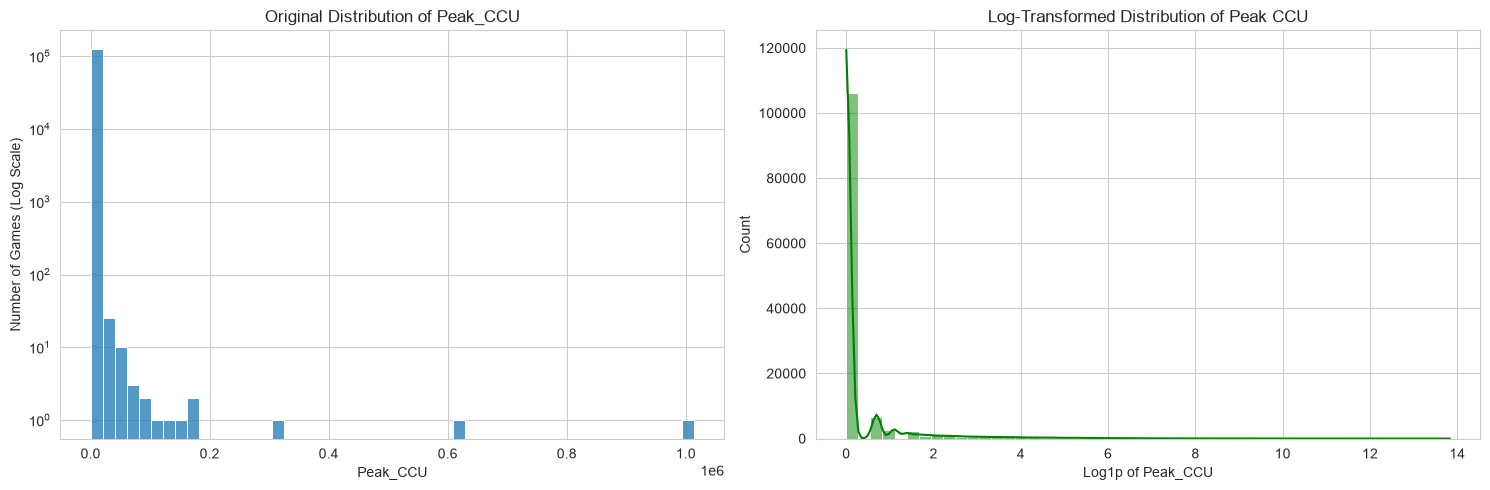

In [30]:
df2_clean['Log_Peak_CCU'] = np.log1p(df2_clean['Peak_CCU'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original highly skewed distribution
sns.histplot(df2_clean['Peak_CCU'], bins=50, ax=axes[0])
axes[0].set_title('Original Distribution of Peak_CCU')
axes[0].set_yscale('log') # Log scale on Y just to make the tiny bars visible
axes[0].set_ylabel('Number of Games (Log Scale)')

# Transformed distribution
sns.histplot(df2_clean['Log_Peak_CCU'], bins=50, ax=axes[1], color='green', kde=True)
axes[1].set_title('Log-Transformed Distribution of Peak CCU')
axes[1].set_xlabel('Log1p of Peak_CCU')

plt.tight_layout()
plt.show()

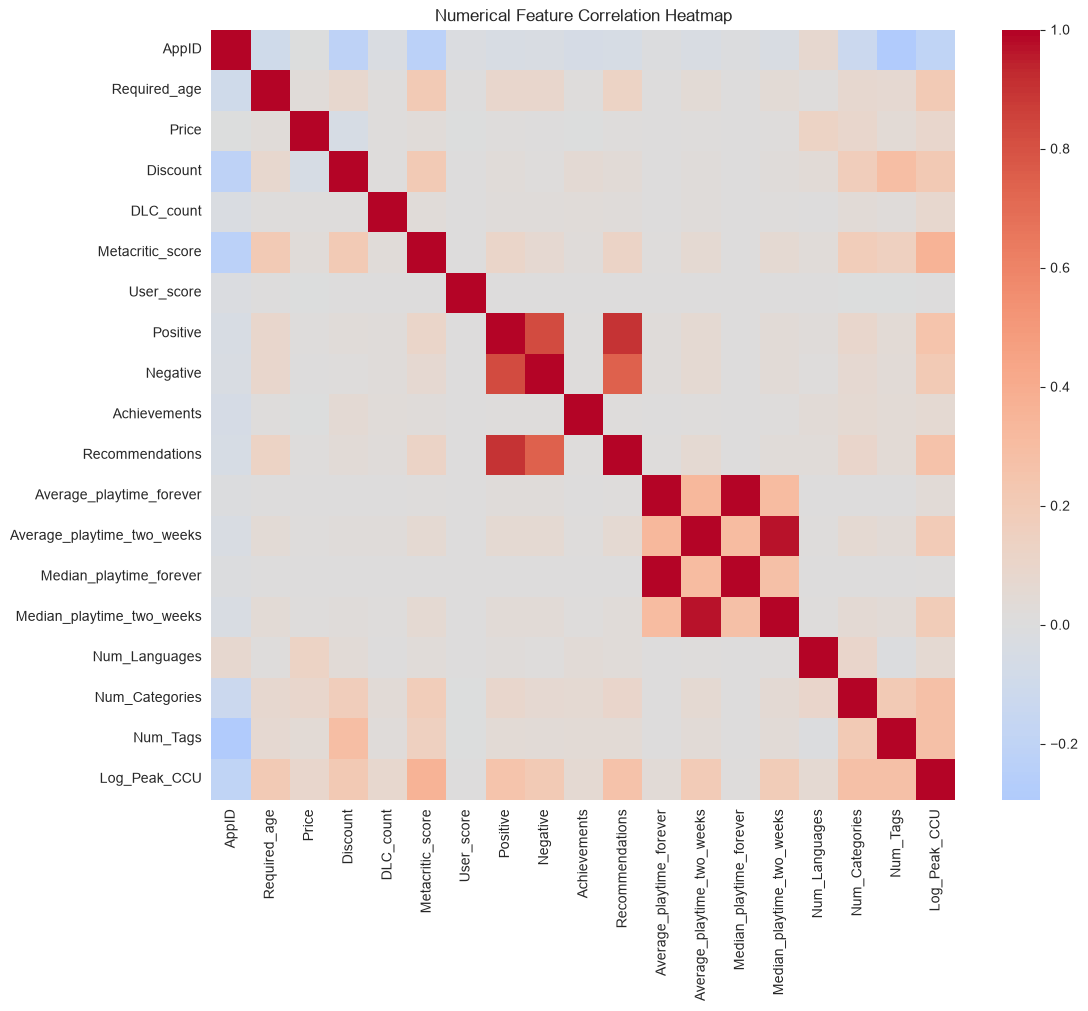

Top numerical correlations with Log_Peak_CCU:

Log_Peak_CCU                  1.000000
Metacritic_score              0.362899
Num_Tags                      0.277026
Num_Categories                0.274868
Recommendations               0.265938
Positive                      0.253650
Discount                      0.213217
Required_age                  0.208806
Negative                      0.208028
Average_playtime_two_weeks    0.199465
Name: Log_Peak_CCU, dtype: float64


In [23]:
plt.figure(figsize=(12, 10))

# Select numerical columns from the cleaned dataframe
numerical_cols = df2_clean.select_dtypes(include=np.number).columns.tolist()

# Drop the original Peak_CCU to avoid redundant perfect correlation
corr_matrix = df2_clean[numerical_cols].drop(columns=['Peak_CCU']).corr()

sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Numerical Feature Correlation Heatmap')
plt.show()

# Print the top numerical predictors for Log_Peak_CCU
print("Top numerical correlations with Log_Peak_CCU:\n")
print(corr_matrix['Log_Peak_CCU'].sort_values(ascending=False).head(10))

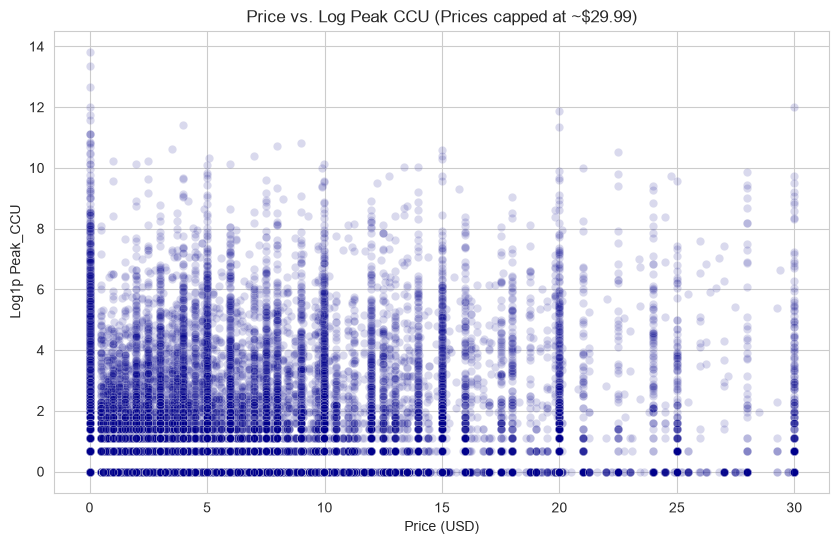

In [46]:
plt.figure(figsize=(10, 6))

# Cap the price at the 99th percentile for a readable visualization
price_cap = df2_clean['Price'].quantile(0.99)
df_price_vis = df2_clean[df2_clean['Price'] <= price_cap]

sns.scatterplot(x='Price', y='Log_Peak_CCU', data=df_price_vis, alpha=0.15, color='darkblue')
plt.title(f'Price vs. Log Peak CCU (Prices capped at ~${price_cap:.2f})')
plt.xlabel('Price (USD)')
plt.ylabel('Log1p Peak_CCU')
plt.show()

## Future Plan

Plan: cap extreme prices (e.g., collector's editions/bundles) at a reasonable percentile rather than dropping, since they are legitimate data points.

# Topic 3 : Aviation Accident Severity Prediction

## Problem Statement

Given the circumstances of a flight (aircraft type, engine type, weather, phase of flight), can we predict accident severity to help identify higher-risk conditions?

## Goals
- Classify accident injury severity from structured incident data
- Surface which operational/mechanical factors (engine type, aircraft category, weather) most
  strongly predict severe outcomes

## Approach
- Use only structured fields (exclude any free-text narrative/remarks column)
- Classification (Random Forest) with class-imbalance handling (class weights or SMOTE),
  since fatal accidents are the minority class
- Tie mechanical/engine-type findings back to an engineering perspective

## Data Info
Data Source : NTSB Aviation Accident Database, 1962-2023 (Kaggle: `https://www.kaggle.com/datasets/yassereleraky/aviation-accident-ntsb?select=AviationData.csv`) 88,889 rowsand 31 columns.

## Data Dictionary
| Column | Type | Description |
| :--- | :--- | :--- |
| **Event.Id** | object | Unique identifier for the NTSB event |
| **Investigation.Type** | object | Indicates if the event was an Accident or an Incident |
| **Accident.Number** | object | Specific NTSB tracking number for the accident |
| **Event.Date** | object | Date the event occurred |
| **Location** | object | City and State/Country of the event |
| **Country** | object | Country where the event occurred |
| **Latitude** | float | Latitude coordinate of the event |
| **Longitude** | float | Longitude coordinate of the event |
| **Airport.Code** | object | 3- or 4-letter code of the associated airport (if applicable) |
| **Airport.Name** | object | Name of the associated airport (if applicable) |
| **Injury.Severity** | object | **Target:** Highest level of injury severity (e.g., Fatal, Serious, Minor) |
| **Aircraft.damage** | object | Extent of damage to the aircraft (e.g., Destroyed, Substantial, Minor) |
| **Aircraft.Category** | object | Type of aircraft (e.g., Airplane, Helicopter, Glider) |
| **Registration.Number** | object | The aircraft's registration tail number (N-number) |
| **Make** | object | Manufacturer of the aircraft (e.g., Cessna, Boeing) |
| **Model** | object | Specific model of the aircraft (e.g., 172M, 737) |
| **Amateur.Built** | object | Indicates if the aircraft was homebuilt/amateur-built (Yes/No) |
| **Number.of.Engines** | float | Total number of engines on the aircraft |
| **Engine.Type** | object | Type of powerplant (e.g., Reciprocating, Turbofan, Turboprop) |
| **FAR.Description** | object | Federal Aviation Regulation part the flight was operating under |
| **Schedule** | object | Indicates if it was a scheduled passenger/cargo flight |
| **Purpose.of.flight** | object | General purpose (e.g., Personal, Instructional, Aerial Application) |
| **Air.carrier** | object | Name of the airline or operator |
| **Total.Fatal.Injuries** | float | Total number of fatalities |
| **Total.Serious.Injuries** | float | Total number of serious injuries |
| **Total.Minor.Injuries** | float | Total number of minor injuries |
| **Total.Uninjured** | float | Total number of people involved who were not injured |
| **Weather.Condition** | object | VMC (Visual) or IMC (Instrument) meteorological conditions |
| **Broad.phase.of.flight** | object | Phase of flight during the event (e.g., Takeoff, Cruise, Approach) |
| **Report.Status** | object | Status of the investigation report (e.g., Probable Cause, Preliminary) |
| **Publication.Date** | object | Date the NTSB report was officially published |

## Loading the Data

In [3]:
# Adjust sep to match what you saw above: '|' is most common for NTSB exports,
# '\t' if it looks tab-separated, or ',' if it's genuinely comma-separated.
df3 = pd.read_csv('./data/AviationData.csv', sep=',', encoding='latin1', low_memory=False)
df3.columns = df3.columns.str.strip()  # NTSB exports often have padded column names
df3.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [12]:
df3['Report.Status'].value_counts()

Report.Status
Probable Cause                                                                                                                                                                                                                                                                                            61754
Foreign                                                                                                                                                                                                                                                                                                    1999
<br /><br />                                                                                                                                                                                                                                                                                                167
Factual                                                                   

In [5]:
df3.shape

(88889, 31)

In [6]:
df3.isnull().sum()

Event.Id                      0
Investigation.Type            0
Accident.Number               0
Event.Date                    0
Location                     52
Country                     226
Latitude                  54507
Longitude                 54516
Airport.Code              38757
Airport.Name              36185
Injury.Severity            1000
Aircraft.damage            3194
Aircraft.Category         56602
Registration.Number        1382
Make                         63
Model                        92
Amateur.Built               102
Number.of.Engines          6084
Engine.Type                7096
FAR.Description           56866
Schedule                  76307
Purpose.of.flight          6192
Air.carrier               72241
Total.Fatal.Injuries      11401
Total.Serious.Injuries    12510
Total.Minor.Injuries      11933
Total.Uninjured            5912
Weather.Condition          4492
Broad.phase.of.flight     27165
Report.Status              6384
Publication.Date          13771
dtype: i

## EDA

In [10]:
#Drop columns with excessive missing values or irrelevant identifiers
# Things like NTSB tracking numbers, specific coordinates, and columns missing 70k+ rows
cols_to_drop = [
    'Event.Id', 'Accident.Number', 'Registration.Number', 
    'Airport.Code', 'Airport.Name', 'Latitude', 'Longitude', 
    'Air.carrier', 'Publication.Date','FAR.Description']
df3_clean = df3.drop(columns=cols_to_drop, errors='ignore')

#Handle the Target Variable ('Injury.Severity')
#First, drop rows where we don't even know the target or other columns with lower nulls
df3_clean = df3_clean.dropna(subset=['Injury.Severity'])

#Next, clean the messy strings for example fatal(12) to just fatal
df3_clean['Clean_Injury_Severity'] = df3_clean['Injury.Severity'].str.extract(r'(Fatal|Non-Fatal|Incident|Minor|Serious)')[0]
df3_clean = df3_clean.dropna(subset=['Clean_Injury_Severity']) # Drop rows that didn't match the main categories
df3_clean = df3_clean.drop(columns=['Injury.Severity']) # Drop the old messy column

#Instead of dropping thousands of rows, we fill them with 'Unknown'
cols_to_fill_unknown = ['Weather.Condition', 'Engine.Type', 'Aircraft.Category', 'Make', 'Model', 'Broad.phase.of.flight','Location']
for col in cols_to_fill_unknown:
    df3_clean[col] = df3_clean[col].fillna('Unknown')

df3_clean['Schedule'] = df3_clean['Schedule'].fillna('UNK')
df3_clean['Amateur.Built'] = df3_clean['Amateur.Built'].fillna('No')

# Fill missing 'Number.of.Engines' with the median (usually 1)
df3_clean['Number.of.Engines'] = df3_clean['Number.of.Engines'].fillna(df3_clean['Number.of.Engines'].median())

# For the injury counts, if they are NaN, it usually means 0 for that category
injury_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']
for col in injury_cols:
    df3_clean[col] = df3_clean[col].fillna(0)

# 5. Check the results (Shape, Nulls, and Value Counts)
print(f"Original Shape: {df3.shape}")
print(f"Cleaned Shape: {df3_clean.shape}\n")

print("Remaining Nulls:")
print(df3_clean.isnull().sum().sort_values(ascending=False).head(5))

print("\nTarget Variable Value Counts (Clean_Injury_Severity):")
print(df3_clean['Clean_Injury_Severity'].value_counts())

print("\nEngine Type Value Counts:")
print(df3_clean['Engine.Type'].value_counts().head(5))

Original Shape: (88889, 31)
Cleaned Shape: (87793, 21)

Remaining Nulls:
Report.Status        5475
Purpose.of.flight    5209
Aircraft.damage      2682
Country               225
Amateur.Built          92
dtype: int64

Target Variable Value Counts (Clean_Injury_Severity):
Clean_Injury_Severity
Non-Fatal    67357
Fatal        17826
Incident      2219
Minor          218
Serious        173
Name: count, dtype: int64

Engine Type Value Counts:
Engine.Type
Reciprocating    69499
Unknown           8248
Turbo Shaft       3602
Turbo Prop        3371
Turbo Fan         2360
Name: count, dtype: int64


## Plotting

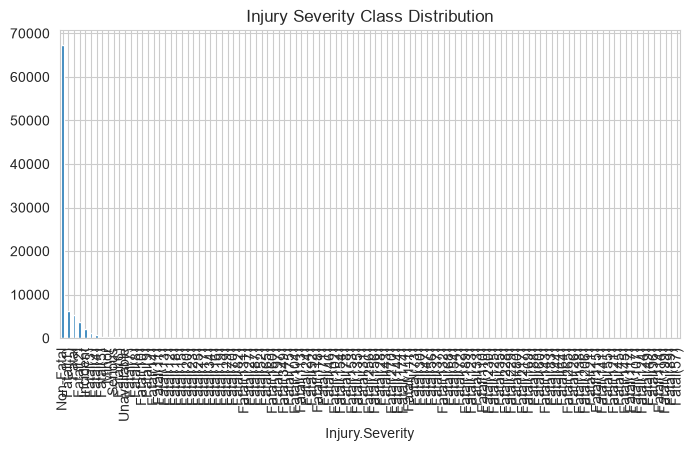

Numerical features: 5
Categorical features: 26
Injury.Severity       Fatal  Fatal(1)  Fatal(10)  Fatal(104)  Fatal(107)  \
Weather.Condition                                                          
IMC                0.102044  0.187835   0.002178    0.000000    0.000168   
UNK                0.000000  0.179907   0.003505    0.001168    0.000000   
Unk                0.578059  0.000000   0.000000    0.000000    0.000000   
VMC                0.041140  0.062759   0.000194    0.000000    0.000000   

Injury.Severity    Fatal(11)  Fatal(110)  Fatal(111)  Fatal(113)  Fatal(115)  \
Weather.Condition                                                              
IMC                 0.000335    0.000000    0.000000    0.000168    0.000168   
UNK                 0.000000    0.000000    0.000000    0.000000    0.000000   
Unk                 0.000000    0.000000    0.000000    0.000000    0.000000   
VMC                 0.000104    0.000013    0.000013    0.000013    0.000000   

Injury.Severity

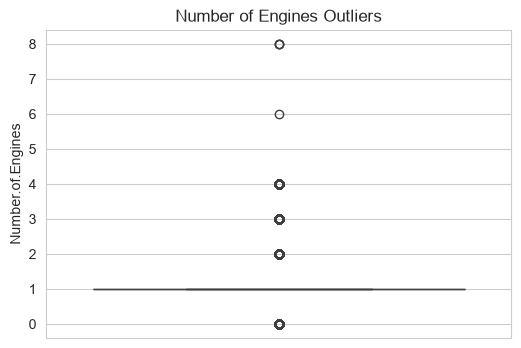

In [13]:
#Target column = Injury.Severity, represents accident outcome severity

#Categorical target -> classification problem. Class balance:
plt.figure(figsize=(8,4))
df3['Injury.Severity'].value_counts().plot(kind='bar')
plt.title('Injury Severity Class Distribution')
plt.show()
# Expect strong imbalance: 'Fatal' is typically a small minority relative to non-fatal outcomes

#Feature types
numerical_cols = df3.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df3.select_dtypes(exclude=np.number).columns.tolist()
print(f'Numerical features: {len(numerical_cols)}')
print(f'Categorical features: {len(categorical_cols)}')

#Correlation / association with target
# Injury.Severity is categorical, so use crosstabs instead of Pearson correlation
print(pd.crosstab(df3['Weather.Condition'], df3['Injury.Severity'], normalize='index'))

#Outliers
plt.figure(figsize=(6,4))
sns.boxplot(y=df3['Number.of.Engines'])
plt.title('Number of Engines Outliers')
plt.show()
# Plan: values like 0 or unusually high engine counts likely reflect data-entry errors and
# should be reviewed/corrected rather than blindly dropped

# Topic 4 : Weather Temperature Prediction

## Problem Statement

Weather conditions affect everything from outdoor mechanical equipment performance to flight safety. Can we predict temperature (or precipitation type) from other atmospheric measurements?

## Goals
- Predict apparent temperature from humidity, wind, pressure, and visibility
- Quantify which atmospheric variables most strongly drive temperature outcomes

## Approach
- Clean known data issues (drop constant 'Loud Cover' column, remove duplicate rows)
- Regression: Linear Regression baseline, then Random Forest
- Optional stretch: compare against Topic 3's Weather.Condition field for a cross-dataset
  discussion of weather's role in aviation risk

## Data Info
Data Source : Weather in Szeged, Hungary 2006-2016 (Kaggle: `https://www.kaggle.com/datasets/budincsevity/szeged-weather?select=weatherHistory.csv`). 96.5k rows, 12 columns.

## Data Dictionary
| Column | Type | Description |
| --- | --- | --- |
| Formatted Date | object | Timestamp of the hourly observation |
| Summary | object | Short weather summary category |
| Precip Type | object | rain / snow |
| Temperature (C) | float | air temperature in Celsius |
| Apparent Temperature (C) | float | **target:** 'Feels like' temperature |
| Humidity | float | Relative humidity (0-1) |
| Wind Speed (km/h) | float | Wind speed |
| Wind Bearing (degrees) | int | Wind direction |
| Visibility (km) | float | Visibility distance |
| Pressure (millibars) | float | Atmospheric pressure |


## Loading the Data

In [14]:
df4 = pd.read_csv('./data/weatherHistory.csv')
print(df4.shape)
df4.head()

(96453, 12)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [15]:
# Known data-quality fixes from prior EDA on this dataset
if 'Loud Cover' in df4.columns:
    df4 = df4.drop(columns=['Loud Cover'])  # constant column, all zeros
df4 = df4.drop_duplicates()
df4.shape

(96429, 11)

In [22]:
df4.rename(columns={'Precip Type': 'Weather_type'}, inplace=True)

## EDA

In [24]:
df4.isnull().sum()

Formatted Date                0
Summary                       0
Weather_type                517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [25]:
df4['Weather_type'].value_counts()

Weather_type
rain    85200
snow    10712
Name: count, dtype: int64

## Plotting

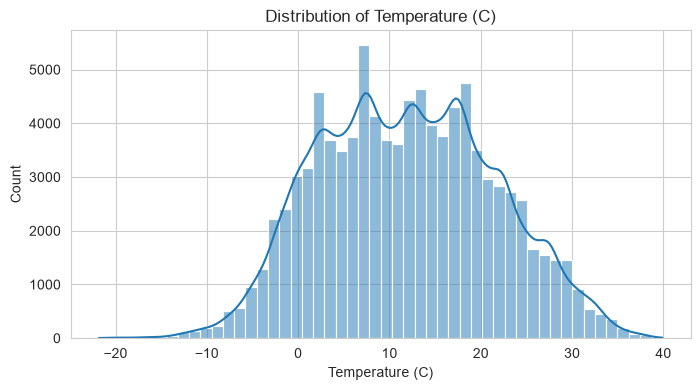

Numerical features: 7
Categorical features: 4
Temperature (C)             1.000000
Apparent Temperature (C)    0.992625
Visibility (km)             0.392939
Wind Bearing (degrees)      0.029888
Wind Speed (km/h)           0.009312
Pressure (millibars)       -0.005481
Humidity                   -0.632331
Name: Temperature (C), dtype: float64


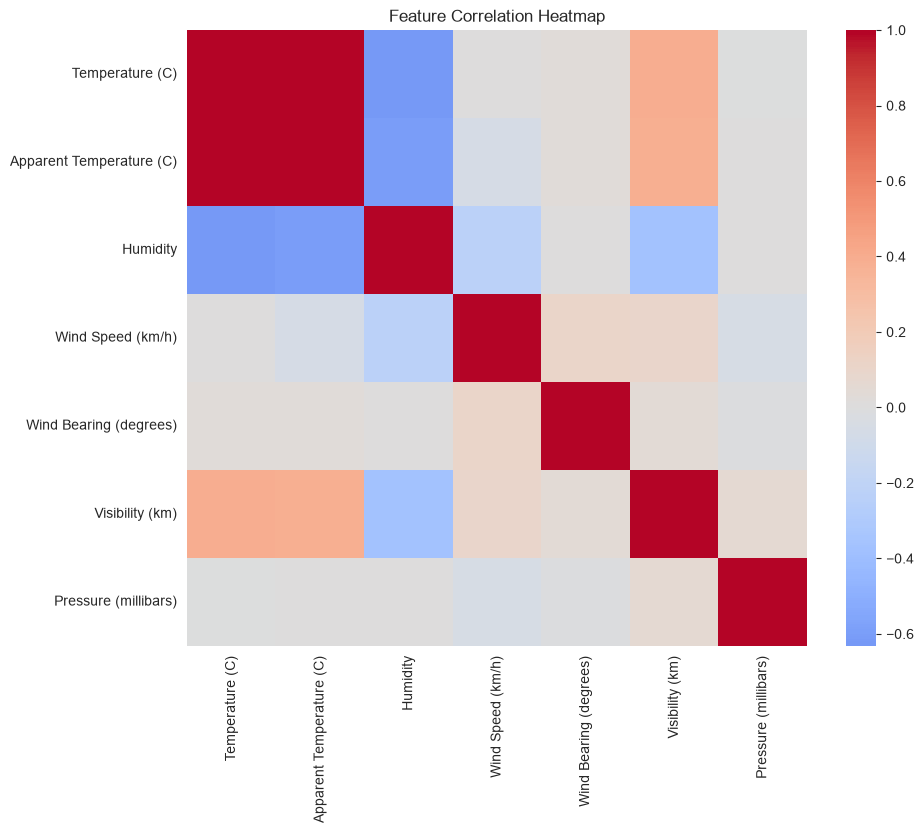

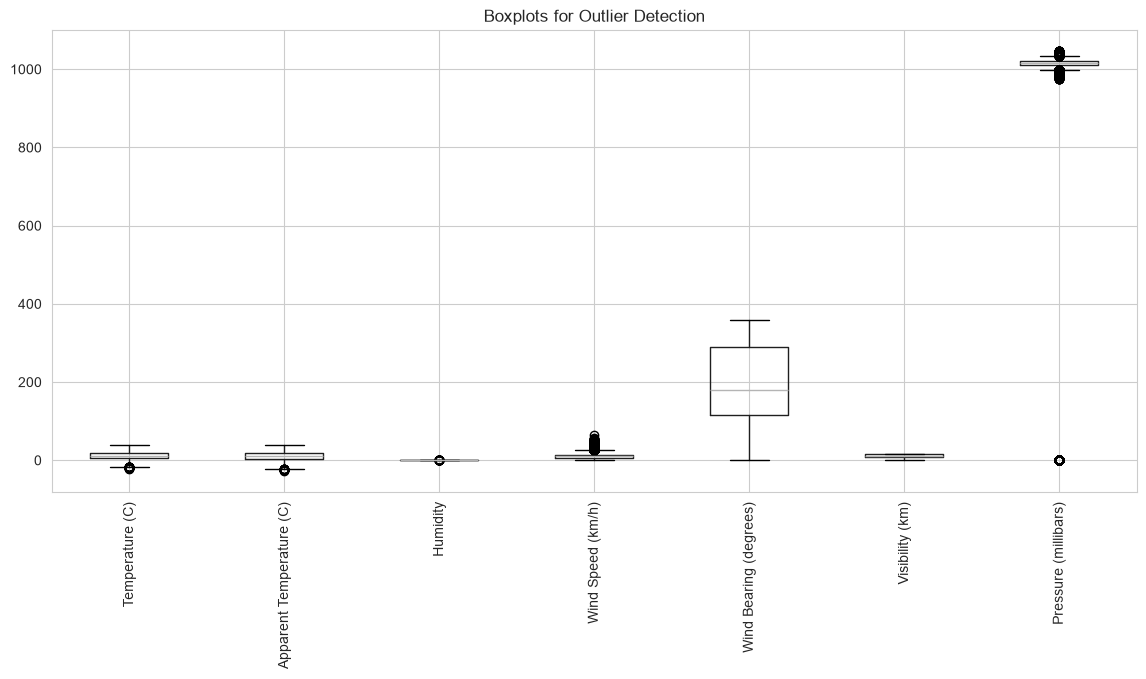

In [35]:
#Target column = Temperature (C), represents measured air temperature

#Continuous target -> regression problem. Distribution:
plt.figure(figsize=(8,4))
sns.histplot(df4['Temperature (C)'], bins=50, kde=True)
plt.title('Distribution of Temperature (C)')
plt.show()

#Feature types
numerical_cols = df4.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df4.select_dtypes(exclude=np.number).columns.tolist()
print(f'Numerical features: {len(numerical_cols)}')
print(f'Categorical features: {len(categorical_cols)}')

#Correlation with target
corr_with_target = df4.corr(numeric_only=True)['Temperature (C)'].sort_values(ascending=False)
print(corr_with_target)

plt.figure(figsize=(10,8))
sns.heatmap(df4.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

#Outliers
plt.figure(figsize=(14,6))
df4[numerical_cols].boxplot(rot=90)
plt.title('Boxplots for Outlier Detection')
plt.show()
# Plan: Humidity/Pressure values of 0 are known sensor errors in this dataset and should be
# treated as missing rather than true zeros; Wind Speed values above ~60 km/h are rare but
# plausible extreme weather events, so cap rather than drop.